In [1]:
# =========================================================
# FULL SEISMIC EVENT RETRIEVAL PIPELINE
#
# 2D Residual CNN
# + Supervised Contrastive Learning
# + Mw Regression
# + Cosine Similarity Retrieval
#
# Dataset shape:
# (N,356,480)
#
# Labels:
# Mw magnitudes
# =========================================================

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

In [2]:


# =========================================================
# DEVICE
# =========================================================

device = "mps" if torch.backends.mps.is_available() else "cpu"

print("Using device:", device)

Using device: mps


In [3]:
geoclaw_compare=np.load("/Users/sanse19p/Documents/vanuatu_fakequakes/data_cubes/geoclaw_toy_database.npz")
data=geoclaw_compare["eta"][:-1]
data=data[:,:,:]
#Global normailization
mean=data.mean()
std=data.std()
data=(data-mean)/(std+1e-8)


In [4]:
magnitudes=np.genfromtxt("/Users/sanse19p/Documents/vanuatu_fakequakes/dtopos_df.txt",skip_header=1,delimiter=",",usecols=1)
# Normalize Mw
mw_mean = magnitudes.mean()
mw_std = magnitudes.std()

magnitudes = (
    magnitudes - mw_mean
) / (mw_std + 1e-8)

magnitudes.shape

(1000,)

In [5]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

(
    train_data,
    test_data,
    train_mw,
    test_mw
) = train_test_split(
    data,
    magnitudes,
    test_size=0.2,
    random_state=42
)

print(train_data.shape)
print(test_data.shape)




(800, 356, 480)
(200, 356, 480)


In [6]:
# =========================================================
# RESIDUAL BLOCK
# =========================================================

class ResidualBlock2D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(
            out_channels
        )
        self.conv2 = nn.Conv2d(
                    out_channels,
                    out_channels,
                    kernel_size=3,
                    stride=1,
                    padding=1,
                    bias=False
                )

        self.bn2 = nn.BatchNorm2d(
            out_channels
        )

        self.shortcut = nn.Sequential()

        if (
            stride != 1
            or
            in_channels != out_channels
        ):

            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(
                    out_channels
                )
            )

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity

        out = F.relu(out)

        return out



In [7]:
# =========================================================
# EVENT ENCODER
# =========================================================

class EventEncoder(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.stem = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True)
        )

        self.layer1 = self._make_layer(
            32,
            64,
            blocks=2,
            stride=2
        )

        self.layer2 = self._make_layer(
            64,
            128,
            blocks=2,
            stride=2
        )
        self.layer3 = self._make_layer(
            128,
            256,
            blocks=2,
            stride=2
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1,1)
        )

        # Embedding head
        self.embedding_head = nn.Sequential(

            nn.Linear(256,256),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(
                256,
                embedding_dim
            )
        )

        # Mw regression head
        self.mw_head = nn.Sequential(

            nn.Linear(
                embedding_dim,
                64
            ),

            nn.ReLU(),

            nn.Linear(64,1)
        )

    def _make_layer(
        self,
        in_channels,
        out_channels,
        blocks,
        stride
    ):

        layers = []
        self.layer3 = self._make_layer(
            128,
            256,
            blocks=2,
            stride=2
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1,1)
        )

        # Embedding head
        self.embedding_head = nn.Sequential(

            nn.Linear(256,256),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(
                256,
                embedding_dim
            )
        )

        # Mw regression head
        self.mw_head = nn.Sequential(

            nn.Linear(
                embedding_dim,
                64
            ),

            nn.ReLU(),

            nn.Linear(64,1)
        )

    def _make_layer(
        self,
        in_channels,
        out_channels,
        blocks,
        stride
    ):

        layers = []
        layers.append(
            ResidualBlock2D(
                in_channels,
                out_channels,
                stride
            )
        )

        for _ in range(1, blocks):

            layers.append(
                ResidualBlock2D(
                    out_channels,
                    out_channels
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.stem(x)

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        embeddings = self.embedding_head(x)

        embeddings = F.normalize(
            embeddings,
            p=2,
            dim=1,
            eps=1e-8
        )

        mw_prediction = self.mw_head(
            embeddings
        )

        return embeddings, mw_prediction



In [8]:
# =========================================================
# SIAMESE NETWORK
# =========================================================

class SiameseNetwork(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.encoder = EventEncoder(
            embedding_dim
        )

    def forward(
        self,
        x1,
        x2
    ):

        z1, mw1 = self.encoder(x1)

        z2, mw2 = self.encoder(x2)

        return z1, z2, mw1, mw2


# ======================

In [9]:
class MwContrastiveDataset(Dataset):

    def __init__(
        self,
        events,
        magnitudes,
        positive_threshold=0.2,
        negative_threshold=1.0
    ):

        self.events = torch.tensor(
            events,
            dtype=torch.float32
        )

        self.magnitudes = np.array(
            magnitudes
        )

        self.n = len(events)

        self.pos_thresh = positive_threshold

        self.neg_thresh = negative_threshold

    def augment(self, x):

        noise = (
            0.01 *
            torch.randn_like(x)
        )

        scale = torch.empty(1).uniform_(
            0.95,
            1.05
        )

        shift = random.randint(-5,5)

        x = torch.roll(
            x,
            shifts=shift,
            dims=1
        )

        x = x * scale + noise

        return x

    def __len__(self):
       return self.n

    def __getitem__(self, idx):

        anchor = self.events[idx]

        anchor_mw = self.magnitudes[idx]

        # Positive or negative
        if random.random() < 0.5:

            candidate_indices = np.where(
                np.abs(
                    self.magnitudes - anchor_mw
                ) < self.pos_thresh
            )[0]

            label = 1.0

        else:

            candidate_indices = np.where(
                np.abs(
                    self.magnitudes - anchor_mw
                ) > self.neg_thresh
            )[0]

            label = 0.0

        candidate_indices = candidate_indices[
            candidate_indices != idx
        ]

        pair_idx = np.random.choice(
            candidate_indices
        )

        pair = self.events[pair_idx]

        pair_mw = self.magnitudes[pair_idx]

        anchor = self.augment(anchor)

        pair = self.augment(pair)

        return (

            anchor.unsqueeze(0),

            pair.unsqueeze(0),

            torch.tensor(
                label,
                dtype=torch.float32
            ),

            torch.tensor(
                anchor_mw,
                dtype=torch.float32
            ),

            torch.tensor(
                pair_mw,
                dtype=torch.float32
            )
        )



In [10]:
# =========================================================
# RETRIEVAL DATASET
# =========================================================

class RetrievalDataset(Dataset):

    def __init__(self, events):

        self.events = torch.tensor(
            events,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.events)

    def __getitem__(self, idx):

        x = self.events[idx]

        return x.unsqueeze(0)


In [11]:
# =========================================================
# CONTRASTIVE LOSS
# =========================================================

class ContrastiveLoss(nn.Module):

    def __init__(
        self,
        margin=1.0
    ):

        super().__init__()

        self.margin = margin

    def forward(
        self,
        z1,
        z2,
        labels
    ):

        distance = torch.norm(
            z1 - z2,
            dim=1
        )

        positive_loss = (
            labels *
            distance.pow(2)
        )

        negative_loss = (
            (1 - labels)
            *
            torch.clamp(
                self.margin - distance,
                min=0
            ).pow(2)
        )

        return (
            positive_loss +
            negative_loss
        ).mean()



In [12]:
# =========================================================
# DATALOADERS
# =========================================================

train_dataset = MwContrastiveDataset(
    train_data,
    train_mw
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

retrieval_dataset = RetrievalDataset(
    train_data
)

retrieval_loader = DataLoader(
    retrieval_dataset,
    batch_size=16,
    shuffle=False
)


In [13]:
# =========================================================
# MODEL
# =========================================================

model = SiameseNetwork(
    embedding_dim=128
).to(device)

contrastive_loss_fn = ContrastiveLoss(
    margin=1.0
)

mw_loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)



In [ ]:
# =========================================================
# TRAINING
# =========================================================

epochs = 200

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for (
        x1,
        x2,
        labels,
        mw1,
        mw2
    ) in train_loader:

        x1 = x1.to(device)

        x2 = x2.to(device)

        labels = labels.to(device)

        mw1 = mw1.to(device)

        mw2 = mw2.to(device)

        z1, z2, pred1, pred2 = model(
            x1,
            x2
        )

        contrastive_loss = (
            contrastive_loss_fn(
                z1,
                z2,
                labels
            )
        )

        regression_loss = (

            mw_loss_fn(
                pred1.squeeze(),
                mw1
            )
           +

            mw_loss_fn(
                pred2.squeeze(),
                mw2
            )
        )

        loss = (
            contrastive_loss
            +
            0.5 * regression_loss
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = (
        total_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch+1}: "
        f"{avg_loss:.4f}"
    )

Epoch 1: 0.1091
Epoch 2: 0.1114
Epoch 3: 0.0978
Epoch 4: 0.1199
Epoch 5: 0.1477
Epoch 6: 0.1273
Epoch 7: 0.0920
Epoch 8: 0.0943
Epoch 9: 0.0993
Epoch 10: 0.0871
Epoch 11: 0.0990
Epoch 12: 0.0870
Epoch 13: 0.0937
Epoch 14: 0.1021
Epoch 15: 0.1232
Epoch 16: 0.0859
Epoch 17: 0.0956
Epoch 18: 0.0842
Epoch 19: 0.0889
Epoch 20: 0.0955
Epoch 21: 0.0735
Epoch 22: 0.0831
Epoch 23: 0.0933
Epoch 24: 0.0778
Epoch 25: 0.0916
Epoch 26: 0.1048
Epoch 27: 0.0832
Epoch 28: 0.0810
Epoch 29: 0.1028
Epoch 30: 0.0719
Epoch 31: 0.0900
Epoch 32: 0.0728
Epoch 33: 0.0883
Epoch 34: 0.0913
Epoch 35: 0.0791
Epoch 36: 0.1234
Epoch 37: 0.0853
Epoch 38: 0.0795
Epoch 39: 0.0655
Epoch 40: 0.0587
Epoch 41: 0.0623
Epoch 42: 0.0733
Epoch 43: 0.0567
Epoch 44: 0.0652
Epoch 45: 0.0661
Epoch 46: 0.0551
Epoch 47: 0.0521
Epoch 48: 0.0593
Epoch 49: 0.0729
Epoch 50: 0.0688
Epoch 51: 0.0594
Epoch 52: 0.0496
Epoch 53: 0.0512
Epoch 54: 0.0455
Epoch 55: 0.0531
Epoch 56: 0.0542
Epoch 57: 0.0417
Epoch 58: 0.0541
Epoch 59: 0.0523
Epoch 

In [16]:
# =========================================================
# BUILD RETRIEVAL DATABASE
# =========================================================

model.eval()

all_embeddings = []

with torch.no_grad():

    for batch in retrieval_loader:

        batch = batch.to(device)

        embeddings, _ = model.encoder(
            batch
        )

        all_embeddings.append(
            embeddings.cpu()
        )

all_embeddings = torch.cat(
    all_embeddings,
    dim=0
)

embeddings_db = (
    all_embeddings
    .numpy()
    .astype(np.float32)
)

embeddings_db = np.ascontiguousarray(
    embeddings_db
)

print(
    "Embedding DB:",
    embeddings_db.shape
)



Embedding DB: (800, 128)


In [17]:
# =========================================================
# SEARCH FUNCTION
# =========================================================

def search_events(
    query_event,
    model,
    embeddings_db,
    train_mw,
    k=5
):

    model.eval()

    query_tensor = torch.tensor(
        query_event,
        dtype=torch.float32
    )

    query_tensor = (
        query_tensor
        .unsqueeze(0)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        query_embedding, pred_mw = (
            model.encoder(query_tensor)
        )

    query_embedding = (
        query_embedding
        .cpu()
        .numpy()[0]
    )

    similarities = (
        embeddings_db @ query_embedding
    )

    topk_indices = np.argsort(
        similarities
    )[-k:][::-1]

    topk_scores = similarities[
        topk_indices
    ]

    retrieved_mw = train_mw[
        topk_indices
    ]

    predicted_mw = (
        pred_mw.item() * mw_std
        + mw_mean
    )

    return (
        topk_indices,
        topk_scores,
        retrieved_mw,
        predicted_mw
    )

In [18]:
# =========================================================
# TEST ON UNSEEN EVENT
# =========================================================
def test_unseen_event(n=0):

    query_event = test_data[n]

    true_mw = (
        test_mw[n] * mw_std
        + mw_mean
    )

    (
        indices,
        scores,
        retrieved_mw,
        predicted_mw
    ) = search_events(
        query_event,
        model,
        embeddings_db,
        train_mw,
        k=5
    )

    print("\nTRUE Mw:", true_mw)

    print(
        "PREDICTED Mw:",
        predicted_mw
    )
    return (indices,scores,retrieved_mw,predicted_mw,true_mw)

In [19]:
(indices,scores,retrieved_mw,predicted_mw,true_mw)=test_unseen_event(0)


TRUE Mw: 7.586199999152183
PREDICTED Mw: 7.484918879983901


In [20]:
geoclaw_compare=np.load("/Users/sanse19p/Downloads/real_event.npz")
real_data=geoclaw_compare["eta"][:,:,:]
# =========================================================
# TEST ON REAL EVENT
# =========================================================
def real_unseen_event(n=0):

    query_event = real_data[n]

    true_mw = (
        7.0
    )

    (
        indices,
        scores,
        retrieved_mw,
        predicted_mw
    ) = search_events(
        query_event,
        model,
        embeddings_db,
        train_mw,
        k=5
    )

    print("\nTRUE Mw:", true_mw)

    print(
        "PREDICTED Mw:",
        predicted_mw
    )
    return (indices,scores,retrieved_mw,predicted_mw,true_mw)

In [45]:
(indices,scores,retrieved_mw,predicted_mw,true_mw)=real_unseen_event(0)
print("\nTop Retrieved Events:\n")

for rank in range(len(indices)):

    mw_value = (
        retrieved_mw[rank]* mw_std
        + mw_mean
    )

    print(
        f"{rank+1}: "
        f"Train Event {indices[rank]} | "
        f"Similarity={scores[rank]:.4f} | "
        f"Mw={mw_value:.2f}"
    )



TRUE Mw: 7.0
PREDICTED Mw: 7.043295759323624

Top Retrieved Events:

1: Train Event 35 | Similarity=0.9995 | Mw=6.74
2: Train Event 634 | Similarity=0.9995 | Mw=6.75
3: Train Event 11 | Similarity=0.9994 | Mw=6.76
4: Train Event 795 | Similarity=0.9994 | Mw=6.72
5: Train Event 649 | Similarity=0.9994 | Mw=6.85


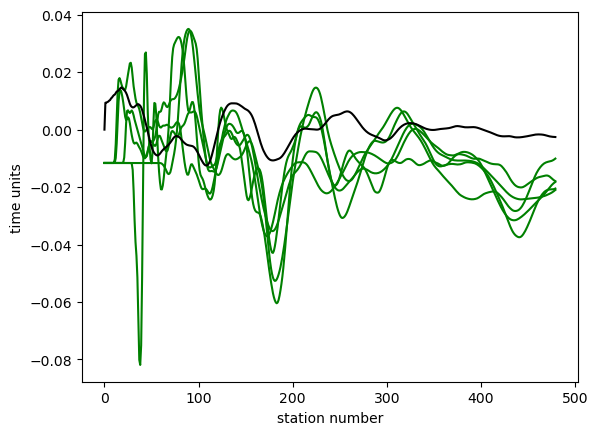

In [48]:
import matplotlib.pyplot as plt
L2_Norm_compare=np.array([6,9,16])
event_chosen=train_data[indices,353,:]
plt.figure()
plt.plot(event_chosen.T,color="g")
plt.plot(real_data[:,353,:].T,color="k")
plt.ylabel("time units")
plt.xlabel("station number")
#plt.xlim(200,400)

plt.show()

In [22]:
array_predicited_mw=[]
array_retrieved_mw=[]
array_true_mw=[]
for i in range(len(test_data)):
    (indices,scores,retrieved_mw,predicted_mw,true_mw)=test_unseen_event(i)
    array_predicited_mw.append(predicted_mw)
    array_retrieved_mw.append(retrieved_mw)
    array_true_mw.append(true_mw)
apm=np.array(array_predicited_mw)
arm=np.array(array_retrieved_mw)
atm=np.array(array_true_mw)


TRUE Mw: 7.586199999152183
PREDICTED Mw: 7.484918879983901

TRUE Mw: 7.754099994936049
PREDICTED Mw: 7.701108136596076

TRUE Mw: 7.952099989964075
PREDICTED Mw: 7.896022850125921

TRUE Mw: 7.660699997281415
PREDICTED Mw: 7.5169529879473185

TRUE Mw: 7.318500005874393
PREDICTED Mw: 7.183401669995341

TRUE Mw: 7.842699992711216
PREDICTED Mw: 7.8003607786989155

TRUE Mw: 7.772699994468986
PREDICTED Mw: 7.727288459340506

TRUE Mw: 7.629699998059855
PREDICTED Mw: 7.529396911635853

TRUE Mw: 7.787799994089809
PREDICTED Mw: 7.723682721050492

TRUE Mw: 7.192800009030843
PREDICTED Mw: 7.145722349310283

TRUE Mw: 8.26499998210685
PREDICTED Mw: 8.18743784159225

TRUE Mw: 7.035400012983311
PREDICTED Mw: 7.071959274489797

TRUE Mw: 7.55549999992309
PREDICTED Mw: 7.408008851597635

TRUE Mw: 8.080499986739826
PREDICTED Mw: 8.0203630821306

TRUE Mw: 8.087899986554003
PREDICTED Mw: 8.015278584535688

TRUE Mw: 7.845499992640906
PREDICTED Mw: 7.794430597601618

TRUE Mw: 7.486500001655748
PREDICTED Mw: 7

In [23]:
arm=arm*mw_std+mw_mean

In [24]:
mag_bins = np.round(np.arange(atm.min(), atm.max(), 0.1), 1)
mag_bins

array([6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9,
       8. , 8.1, 8.2, 8.3, 8.4, 8.5])

/var/folders/7z/qr9m39ln28v0nn0s2bxdrwzh0000gp/T/ipykernel_17290/660507224.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


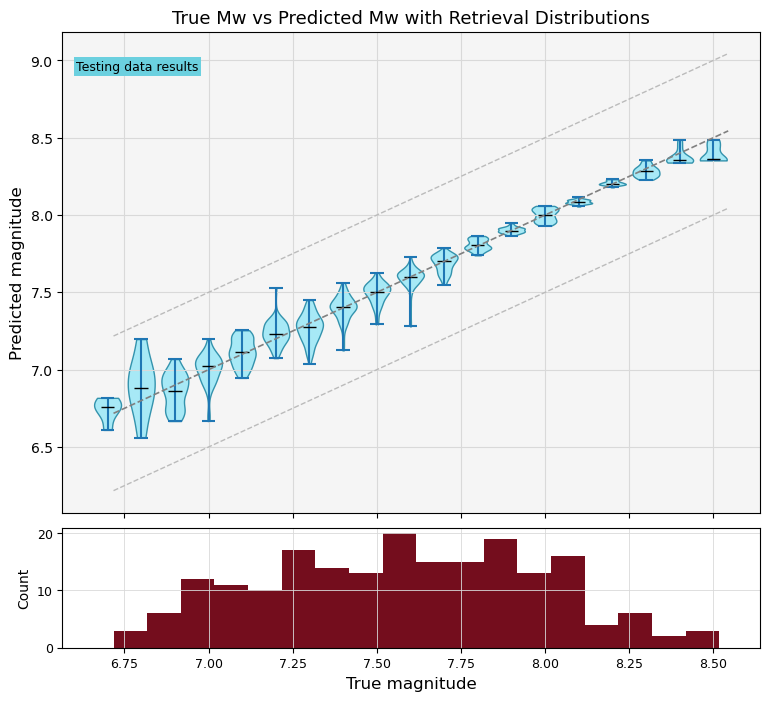

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes 
# ========================================================= # INPUTS FROM NEURAL NETWORK # =========================================================
#  # # true_mw: # shape = (N,) # catalog / ground-truth magnitudes # # predicted_mw: # shape = (N,)
#  # neural network predicted magnitudes # # retrieved_mw: # list of retrieved magnitudes for each event
#  # # Example: # retrieved_mw[i] = [5 nearest Mw values] # # =========================================================
true_mw=atm
predicted_mw=apm
retrieved_mw=arm
 # ========================================================= 
# # MAGNITUDE BINS # ========================================================= 
mag_bins = np.round( np.arange(atm.min(), atm.max(), 0.1), 1 )
bin_centers = mag_bins
#  # ---------------------------------------------------------
#  # Build violin distributions from retrieved magnitudes
#  # --------------------------------------------------------- 
violin_data = []
for m in mag_bins:
    mask = ( (true_mw >= m - 0.05) & (true_mw < m + 0.05) )
    selected = retrieved_mw[mask]
    if len(selected) == 0: 
        violin_data.append( np.array([np.nan]) )
        continue
    values = np.concatenate(selected)
    violin_data.append(values)
#  # =========================================================
#  # HISTOGRAMS # ========================================================= 
hist_main = true_mw
fig, (ax, axhist) = plt.subplots(
    2,
    1,
    figsize=(9, 8),
    sharex=True,
    gridspec_kw={
        'height_ratios': [4, 1],
        'hspace': 0.05
    }
)

# ---------------------------------------------------------
# Background
# ---------------------------------------------------------

ax.set_facecolor("#f5f5f5")

ax.grid(
    color="#d9d9d9",
    linewidth=0.8
)

# =========================================================
# VIOLIN PLOTS
# =========================================================

parts = ax.violinplot(
    violin_data,
    positions=bin_centers,
    widths=0.08,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

for body in parts['bodies']:

    body.set_facecolor("#9fe8f7")

    body.set_edgecolor("#2389a5")

    body.set_alpha(0.9)

parts['cmedians'].set_color('black')

parts['cmedians'].set_linewidth(1)

# =========================================================
# DIAGONAL REFERENCE LINES
# =========================================================

xline = np.linspace(atm.min(), atm.max(), 300)

ax.plot(
    xline,
    xline,
    '--',
    color='gray',
    linewidth=1.2
)

ax.plot(
    xline,
    xline + 0.5,
    '--',
    color='#bbbbbb',
    linewidth=1
)

ax.plot(
    xline,
    xline - 0.5,
    '--',
    color='#bbbbbb',
    linewidth=1
)

# =========================================================
# HISTOGRAM BELOW MAIN PLOT
# =========================================================

bins = np.arange(atm.min(), atm.max(), 0.1)

axhist.hist(
    hist_main,
    bins=bins,
    color='#6d0010',
    alpha=0.95
)

axhist.set_ylabel("Count", fontsize=10)

axhist.grid(
    color="#d9d9d9",
    linewidth=0.6
)

axhist.tick_params(labelsize=9)

# =========================================================
# TEXT
# =========================================================
'''
ax.text(
    0.015,
    0.965,
    "(a)",
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    va='top'
)
''' 
ax.text(
    0.02,
    0.92,
    "Testing data results",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(
        facecolor='#6bd0df',
        edgecolor='none',
        pad=2
    )
)

# =========================================================
# AXES
# =========================================================

ax.set_ylabel(
    "Predicted magnitude",
    fontsize=12
)

ax.tick_params(labelsize=10)

axhist.set_xlabel(
    "True magnitude",
    fontsize=12
)

# =========================================================
# TITLE
# =========================================================

ax.set_title(
    "True Mw vs Predicted Mw with Retrieval Distributions",
    fontsize=13
)

plt.tight_layout()

plt.show()

In [26]:
(indices,scores,retrieved_mw,predicted_mw,true_mw)=test_unseen_event(50)
print("\nTop Retrieved Events:\n")

for rank in range(len(indices)):

    mw_value = (
        retrieved_mw[rank]* mw_std
        + mw_mean
    )

    print(
        f"{rank+1}: "
        f"Train Event {indices[rank]} | "
        f"Similarity={scores[rank]:.4f} | "
        f"Mw={mw_value:.2f}"
    )






TRUE Mw: 7.696099996392487
PREDICTED Mw: 7.636549406198132

Top Retrieved Events:

1: Train Event 239 | Similarity=1.0000 | Mw=7.68
2: Train Event 269 | Similarity=1.0000 | Mw=7.69
3: Train Event 322 | Similarity=1.0000 | Mw=7.68
4: Train Event 387 | Similarity=1.0000 | Mw=7.66
5: Train Event 491 | Similarity=1.0000 | Mw=7.69


In [27]:
mw_value

np.float64(7.691899996497953)

In [28]:
# =========================================================
# SAVE MODEL
# =========================================================

torch.save(
    model.state_dict(),
    "seismic_retrieval_model_120min_test.pth"
)

print("\nModel saved.")


Model saved.


In [29]:
sims = embeddings_db @ embeddings_db.T

print(sims.mean())
print(sims.min())
print(sims.max())

0.51057565
-0.859791
1.0000006


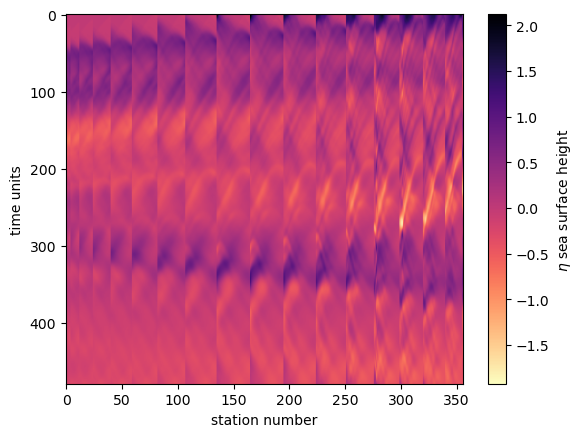

In [30]:
import matplotlib.pyplot as plt
L2_Norm_compare=np.array([6,9,16])
event_chosen=test_data[50,:,:]
plt.figure()
plt.imshow(event_chosen.T,aspect="auto",cmap="magma_r")
plt.ylabel("time units")
plt.xlabel("station number")
#plt.xlim(200,400)
plt.colorbar(label=r"$\eta$ sea surface height")
plt.show()

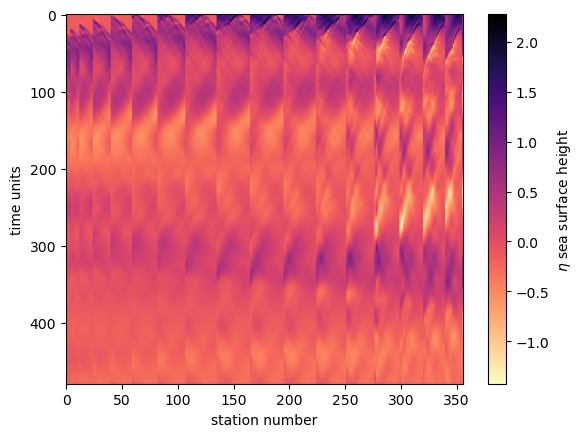

In [31]:
import matplotlib.pyplot as plt
L2_Norm_compare=np.array([6,9,16])
event_chosen_2=train_data[586,:,:]
plt.figure()
plt.imshow(event_chosen_2.T,aspect="auto",cmap="magma_r")
plt.ylabel("time units")
plt.xlabel("station number")
#plt.xlim(200,400)
plt.colorbar(label=r"$\eta$ sea surface height")
plt.show()

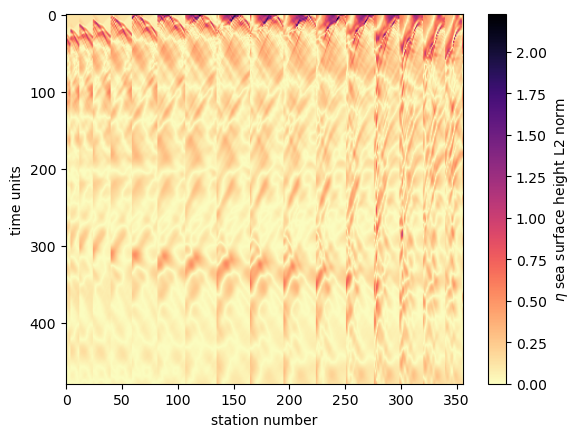

In [32]:
L2_norm_select=(np.abs(event_chosen-train_data[586,:,:])**2)**(0.5)
#L2_norm_select=np.linalg.norm(event_chosen-train_data[619,:,:])
plt.figure()
plt.imshow(L2_norm_select.T,aspect="auto",cmap="magma_r")
plt.ylabel("time units")
plt.xlabel("station number")
#plt.xlim(200,400)
plt.colorbar(label=r"$\eta$ sea surface height L2 norm")
plt.show()